# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada no algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
# Importando dataframes de treino e teste
x_train = pd.read_csv('xp_train_bal.csv')
x_test = pd.read_csv('Xp_test.csv')
y_train = pd.read_csv('yp_train_bal.csv')
y_test = pd.read_csv('Yp_test.csv')

In [4]:
# Verificação das bases de dados
x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 252 non-null    int64  
 1   Gender              252 non-null    int64  
 2   Income              252 non-null    float64
 3   Education           252 non-null    int64  
 4   Marital Status      252 non-null    int64  
 5   Number of Children  252 non-null    int64  
 6   Home Ownership      252 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 13.9 KB


In [5]:
y_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Credit Score  252 non-null    int64
dtypes: int64(1)
memory usage: 2.1 KB


In [6]:
x_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 41 non-null     int64  
 1   Gender              41 non-null     int64  
 2   Income              41 non-null     float64
 3   Education           41 non-null     int64  
 4   Marital Status      41 non-null     int64  
 5   Number of Children  41 non-null     int64  
 6   Home Ownership      41 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 2.4 KB


In [7]:
y_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Credit Score  41 non-null     int64
dtypes: int64(1)
memory usage: 460.0 bytes


In [9]:
y_train.value_counts()

Credit Score
0               84
2               84
1               84
Name: count, dtype: int64

Bases carregadas corretamente e devidamente balanceadas no treino.

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Para a aplicação do algoritmo da árvore de decisão precisamos:
* Separar a base de dados em treino e teste;
* Balancear a base de treino para que o modelo tenha uma eficácia melhor;
* Criar uma variável que vai receber o algoritmo;
* Definir como essa árvore será montada por meio da escolha de parâmetros;
* Esses parâmetros podem ser relacionados à poda (definida de acordo com a avaliação de importância de features pelo modelo), ao número máximo de nós, folhas, escolha de método (gini ou entropia)...;
* Aplicar o modelo para previsões da base de teste;
* Avaliar o modelo de acordo com os resultados da sua aplicação na base de teste;
* Essa avaliação contém parâmetros como precisão (quantos positivos foram identificados dentro da amostra), recall (quantos positivos foram identificados dentro da quantia de positivos reais) e F1-score (que realiza uma ponderação dos anteriores);
* Aplicação de correção e melhorias ao modelo por meio da poda de features e outros parâmetros.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [12]:
# Modelando árvore para score
tree_score = DecisionTreeClassifier(criterion='gini', random_state=0)
tree_score.fit(x_train, y_train)

pred = tree_score.predict(x_train)
acc = accuracy_score(y_train, pred)
print(f'Acurácia: {acc}')
print('\n')
relatorio = classification_report(y_train, pred)
print(relatorio)

Acurácia: 1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [13]:
# Previsões para a base de teste
pred_t = tree_score.predict(x_test)
acc_t = accuracy_score(y_test, pred_t)
print(f'Acurácia: {acc_t}')
print('\n')
relatorio_t = classification_report(y_test, pred_t)
print(relatorio_t)

Acurácia: 0.975609756097561


              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.97      0.98        29
           2       1.00      1.00      1.00         6

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41



O modelo obteve um score levemente menor na fase de teste, o que já era esperado pela falta de balanceamento natural da base de teste.

No score alto o modelo teve nota máxima em todos os parâmetros.

A diferença entre o score médio e o baixo reside no fato de a quantia de previsões positivas deste dentro do espaço amostral ter sido inferior àquela, porém superior em relação a comparação entre positivos previstos e reais.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

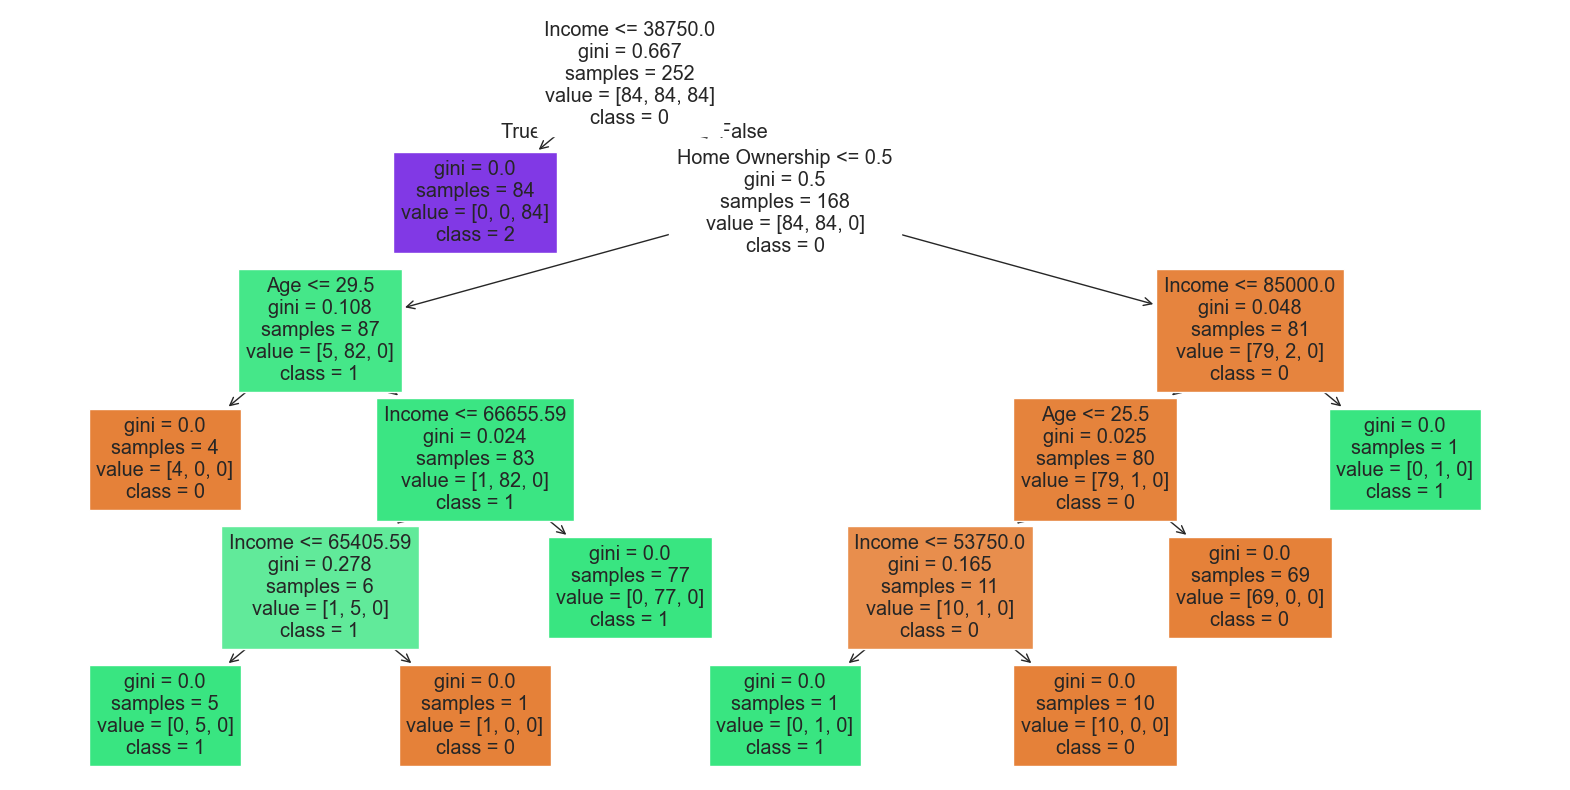

In [18]:
# Árvore de decisão score
plt.figure(figsize=(20,10))
plt.style.use('seaborn-v0_8-whitegrid')
plot_tree(tree_score, filled=True, feature_names=x_train.columns, class_names=['0', '1', '2'])
plt.show()

A árvore criada pelo modelo usou poucas features, o que resultou numa complexidade de avaliação média-baixa.

A principal feature parece income, seguida de home ownership, e idade.

A profundidade da árvore é 5.

# 6) Identifique as 2 principais features do modelo.


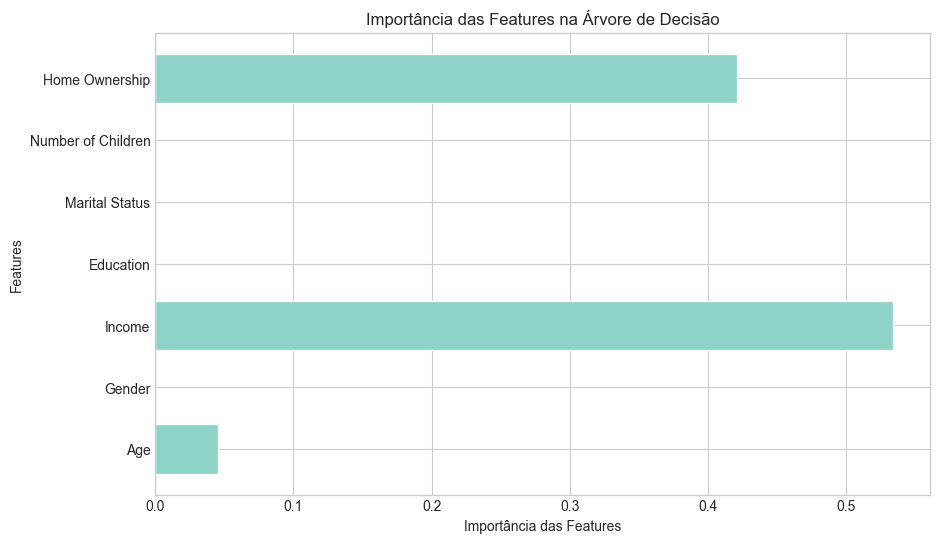

In [19]:
# Principais features do modelo
princ_feat = tree_score.feature_importances_
nome_feat = x_train.columns

plt.figure(figsize=(10, 6))
plt.barh(nome_feat, princ_feat)
plt.style.use('seaborn-v0_8-whitegrid')
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

As duas principais features para o modelo são income e home ownership.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [21]:
# Modelo com principais features
x_train_feat = x_train[['Income', 'Home Ownership']]
x_test_feat = x_test[['Income', 'Home Ownership']]

tree_score_feat = DecisionTreeClassifier(criterion='gini', random_state=0)
tree_score_feat.fit(x_train_feat, y_train)

# Previsões para a base de teste com modelo features
pred_f = tree_score_feat.predict(x_test_feat)
acc_f = accuracy_score(y_test, pred_f)
print(f'Acurácia: {acc_f}')
print('\n')
relatorio_f = classification_report(y_test, pred_f)
print(relatorio_f)

Acurácia: 0.9512195121951219


              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



Após a adaptação das features no modelo uma queda na acurácia pode ser observada.

Apesar de termos mantido as duas features mais importantes no modelo, como ele só dependia de 3 dentre todas as possíveis, enfraquecemos a força da análise feita.

Acho que se estivéssemos frente à uma base dados com muitas features sendo usadas essa poda seria mais eficaz.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

A acurácia da árvore com features modificadas foi ligeiramente menor, mas o recall foi maior.

A árvore do primeiro modelo se saiu superior ao modelo de Bayes em ambos os quesitos de avaliação. Isso pode estar relacionado ao fato da análise ser mais complexa e completa no modelo de árvore de decisão.